In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from scipy import stats
import numpy as np
import os
import time
import bowties as bt

print(
    f"""
# PyTensor version: {pytensor.__version__}
# PyMC version: {pm.__version__}
"""
)

pytensor.config.change_flags(exception_verbosity="high",optimizer=None)


# PyTensor version: 2.38.3
# PyMC version: 5.28.4



In [2]:

nb_samples=2000

with bt.bowtie() as airprox:

    airprox.context = 'Flight activity'
    #variables
    # EventSignal = pm.ConstantData('True',1)
    # NoEventSignal = pm.ConstantData('False',0)
    a = pm.Normal("a", mu=0.0, sigma=5.0)
    b = pm.Normal("b", mu=0.0, sigma=1.0)
    c = pm.Normal("c", mu=0.0, sigma=5.0)
    d = pm.Normal("d", mu=0.0, sigma=1.0)
    e = pm.Normal("e", mu=0.0, sigma=5.0)
    f = pm.Normal("f", mu=0.0, sigma=5.0)
    g = pm.Normal("g", mu=0.0, sigma=5.0)
    splitdist = pm.DiscreteUniform('Even Split',lower=0,upper=1)

    #Causes 
    cause1 = pm.Deterministic('Cause\nBad Luck',bt.cause(splitdist))
    cause2 = pm.Deterministic('Cause\nNo Flight Plan',bt.cause(bt.invert(splitdist)))
    airprox.causes = ['Cause\nBad Luck','Cause\nNo Flight Plan']
        

    #Preventative Barriers
    barrier1 = pm.Deterministic('Barrier\nFlight Plan',bt.barrier(c,cause1))
    barrier2 = pm.Deterministic('Barrier\nATC Warning',bt.barrier(d,bt.combine((cause2,barrier1))))
    barrier3 = pm.Deterministic('Barrier\nPilot Sky\nScanning',bt.barrier(d,barrier2,threshold=2))
    airprox.preventativebarriers = ['Barrier\nFlight Plan','Barrier\nATC Warning','Barrier\nPilot Sky\nScanning']
    
    #Top Event
    te = pm.Deterministic('Top Event\nImminent loss\nof seperation',bt.topevent(barrier3))
    airprox.topevent = 'Top Event\nImminent loss\nof seperation'
    
    #Mitigation Barriers
    barrier4 = pm.Deterministic('Barrier\nSituational Awareness',bt.barrier(e,te))
    airprox.mitigationbarriers = ['Barrier\nSituational Awareness']
    
    #Consequences
    consequence1 = pm.Deterministic('Consequence\nCollision',bt.consequence(barrier4))
    consequence2 = pm.Deterministic('Consequence\nAvoiding Action',bt.consequence(bt.inverting_and(barrier4,te)))
    airprox.consequences = ['Consequence\nCollision','Consequence\nAvoiding Action']
    trace = pm.sample(draws=nb_samples, random_seed=1000)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [a, b, c, d, e, f, g]
>Metropolis: [Even Split]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [3]:
print(airprox.allbarriers())
print(list(airprox.named_vars.keys()))
# ap_effectiveness = airprox.barrier_effectiveness(trace)


bowtieplot = bt.plot_all_elements(airprox)
bowtieplot.view()
bowtienx = airprox.plot_bowtie(trace,
                                e2r=[('Top Event\nImminent loss\nof seperation','Consequence\nAvoiding Action')]) #removing extra edge caused by inverting_and function

['Barrier\nFlight Plan', 'Barrier\nATC Warning', 'Barrier\nPilot Sky\nScanning', 'Barrier\nSituational Awareness']
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'Even Split', 'Cause\nBad Luck', 'Cause\nNo Flight Plan', 'Barrier\nFlight Plan', 'Barrier\nATC Warning', 'Barrier\nPilot Sky\nScanning', 'Top Event\nImminent loss\nof seperation', 'Barrier\nSituational Awareness', 'Consequence\nCollision', 'Consequence\nAvoiding Action']



(process:105727): Gtk-WARNING **: 14:29:25.789: Locale not supported by C library.
	Using the fallback 'C' locale.

(evince:105727): Gtk-WARNING **: 14:29:25.888: Theme parsing error: gtk-keys.css:1:0: Failed to import: Error opening file /snap/code/235/usr/share/themes/Default/gtk-3.0/gtk-keys.css: Permission denied
Gtk-Message: 14:29:25.889: Failed to load module "canberra-gtk-module"
Gtk-Message: 14:29:25.890: Failed to load module "canberra-gtk-module"
/home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so: cannot open shared object file: Permission denied
Failed to load module: /home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so


In [7]:
bowtienx.view()

'.gv.pdf'


(process:106333): Gtk-WARNING **: 14:30:51.488: Locale not supported by C library.
	Using the fallback 'C' locale.

(evince:106333): Gtk-WARNING **: 14:30:51.569: Theme parsing error: gtk-keys.css:1:0: Failed to import: Error opening file /snap/code/235/usr/share/themes/Default/gtk-3.0/gtk-keys.css: Permission denied
Gtk-Message: 14:30:51.570: Failed to load module "canberra-gtk-module"
Gtk-Message: 14:30:51.580: Failed to load module "canberra-gtk-module"
/home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so: cannot open shared object file: Permission denied
Failed to load module: /home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so


In [4]:
model_nodes = list(airprox.named_vars.keys())
RVNodes = ['a','b','c','d','e','f','g']
DeterministicNodes = [a for a in model_nodes if a not in RVNodes]


(process:105999): Gtk-WARNING **: 14:30:02.197: Locale not supported by C library.
	Using the fallback 'C' locale.

(evince:105999): Gtk-WARNING **: 14:30:02.293: Theme parsing error: gtk-keys.css:1:0: Failed to import: Error opening file /snap/code/235/usr/share/themes/Default/gtk-3.0/gtk-keys.css: Permission denied
Gtk-Message: 14:30:02.294: Failed to load module "canberra-gtk-module"
Gtk-Message: 14:30:02.296: Failed to load module "canberra-gtk-module"
/home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so: cannot open shared object file: Permission denied
Failed to load module: /home/joni/snap/code/common/.cache/gio-modules/libdconfsettings.so


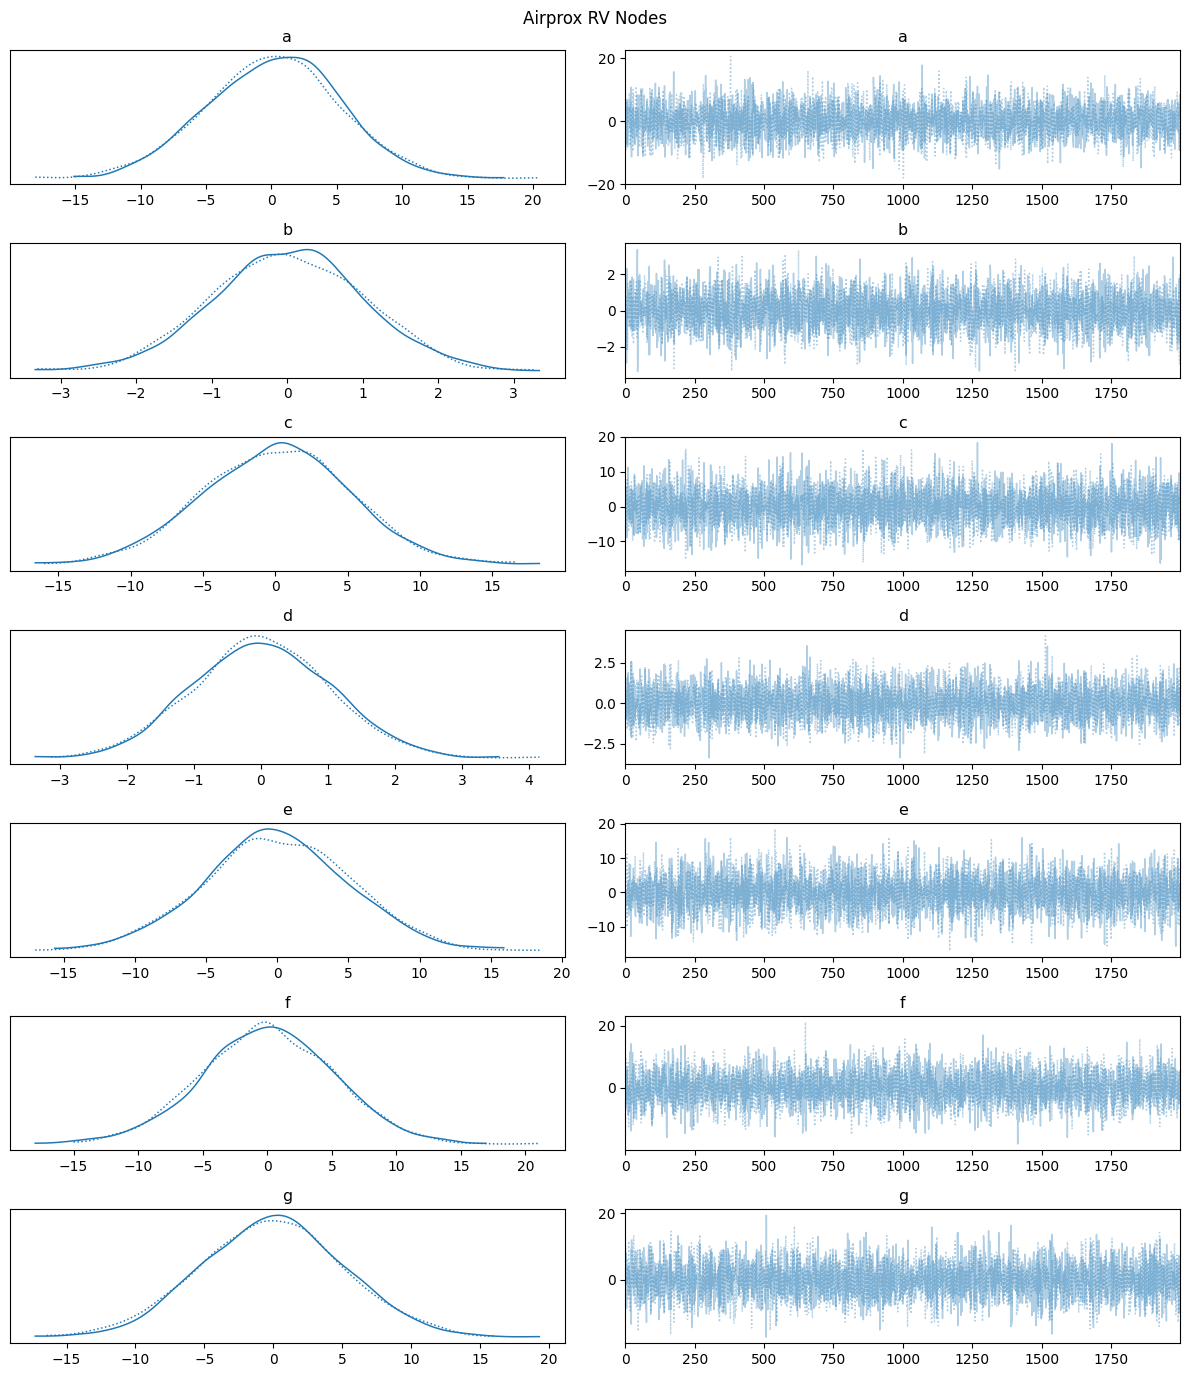

In [5]:
az.rcParams["plot.max_subplots"]=100
az.plot_trace(trace,RVNodes)
plt.suptitle('Airprox RV Nodes')
plt.tight_layout()
plt.show()

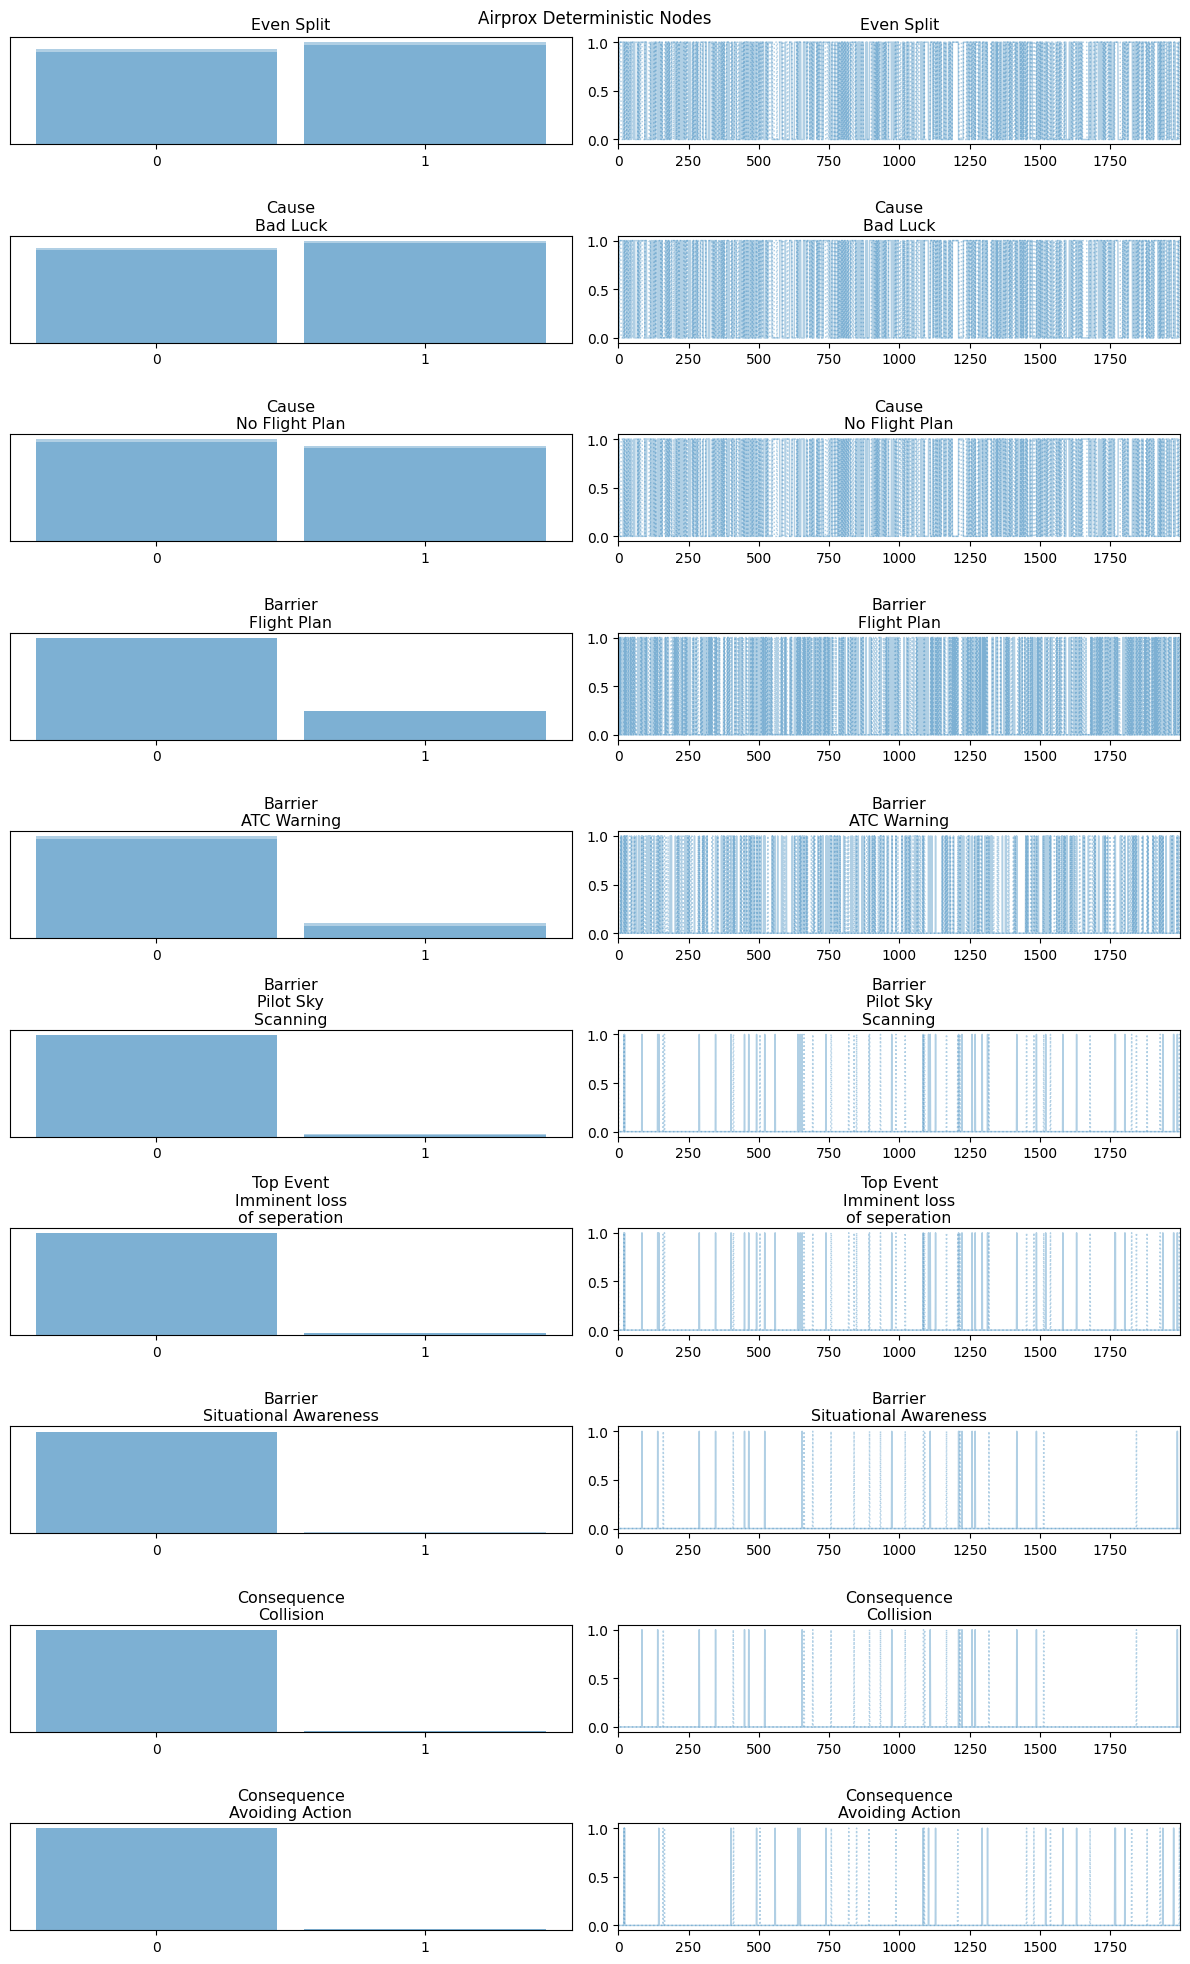

In [6]:

az.rcParams["plot.max_subplots"]=100
az.plot_trace(trace,DeterministicNodes)
plt.suptitle('Airprox Deterministic Nodes')
plt.tight_layout()
plt.show()